# Crecimiento de Empresas Colombianas

### Proyecto Final - Optimización e Inteligencia Artificial

---

## Integrantes

<table>
  <tr><th>Nombre</th><th>Correo</th></tr>
  <tr><td>Dylan Ramirez Blanquicet</td><td><a href="mailto:dyramirezb@unal.edu.co">dyramirezb@unal.edu.co</a></td></tr>
  <tr><td>Andres Felipe Guerra Amaris</td><td><a href="mailto:anguerraa@unal.edu.co">anguerraa@unal.edu.co</a></td></tr>
  <tr><td>Jerónimo Hoyos Botero</td><td><a href="mailto:jhoyosbo@unal.edu.co">jhoyosbo@unal.edu.co</a></td></tr>
  <tr><td>Pedro Aristizabal Alzate</td><td><a href="mailto:paristizabala@unal.edu.co">paristizabala@unal.edu.co</a></td></tr>
</table>

## Índice

1. [Planteamiento del problema](#sec-1)
    1. [Objetivo](#sec-1-1)
    1. [Diccionario de datos](#sec-1-2)
    1. [Importaciones](#sec-1-3)
2. [Formateo de datos](#sec-2)
    1. [Carga de datos](#sec-2-1)
    1. [Nombres de columnas](#sec-2-2)
    1. [Variables financieras](#sec-2-3)
    1. [NIT, CIIU y año de corte](#sec-2-4)
3. [Análisis exploratorio (EDA)](#sec-3)
    1. [Univariado](#sec-3-1)
    1. [Multivariado](#sec-3-2)
    1. [Cobertura del ranking por año](#sec-3-3)
4. [Limpieza de datos](#sec-4)
    1. [Duplicados](#sec-4-1)
    1. [Ciudad de domicilio](#sec-4-2)
    1. [Departamento y región](#sec-4-3)
    1. [Razón social por NIT](#sec-4-4)
    1. [Activos totales en cero](#sec-4-5)
    1. [Entidades de Supersalud](#sec-4-6)
5. [Preparación de datos](#sec-5)
    1. [Variable objetivo](#sec-5-1)
    1. [Variables nuevas](#sec-5-2)
    1. [Tabla final y exportación](#sec-5-3)
6. [Modelado](#sec-6)
    1. [Datos para el modelo](#sec-6-1)
    1. [Balanceo con SMOTE](#sec-6-2)
    1. [Regresión logística](#sec-6-3)
    1. [Naive Bayes](#sec-6-4)
    1. [K vecinos más cercanos](#sec-6-5)
    1. [SVM](#sec-6-6)
    1. [Árbol de decisión](#sec-6-7)
    1. [Random forest con grid search](#sec-6-8)
    1. [Random forest con búsqueda bayesiana](#sec-6-9)
    1. [Red neuronal](#sec-6-10)
    1. [Comparación en test](#sec-6-11)
    1. [Matrices de confusión](#sec-6-12)

<a id="sec-1"></a>
## 1. Planteamiento del problema

<a id="sec-1-1"></a>
### 1.1 Objetivo

La Superintendencia de Sociedades publica cómo les fue a las empresas, pero no anticipa cuáles entrarán en problemas. Este proyecto, del reto *Datos al Ecosistema 2025* del MinTIC, busca predecir si una empresa tendrá **pérdidas** o **patrimonio negativo** el año siguiente, a partir de su sector, ubicación y cifras financieras.

El modelo aprende con años pasados y se evalúa en 2025, para servir como alerta temprana sobre las empresas con más riesgo. Los datos vienen de [10.000 Empresas más Grandes del País](https://www.datos.gov.co/Comercio-Industria-y-Turismo/10-000-Empresas-mas-Grandes-del-Pa-s/6cat-2gcs/about_data).

<a id="sec-1-2"></a>
### 1.2 Diccionario de datos

| Variable | Columna | Tipo | Descripción |
|---|---|---|---|
| NIT | nit | Categórica nominal (identificador) | Número tributario único de la empresa. Sin valor predictivo. |
| RAZÓN SOCIAL | company_name | Categórica nominal (identificador) | Nombre legal de la empresa. |
| SUPERVISOR | supervisor | Categórica nominal | Superintendencia que vigila a la empresa. |
| REGIÓN | region | Categórica nominal | Región geográfica del domicilio. |
| DEPARTAMENTO DOMICILIO | department | Categórica nominal | Departamento de la sede legal. |
| CIUDAD DOMICILIO | city | Categórica nominal | Municipio de la sede legal. |
| CIIU | ciiu | Categórica nominal (código) | Código de actividad económica. Sin orden implícito. |
| MACROSECTOR | macrosector | Categórica nominal | Sector económico amplio (Minero, Comercio, etc.). |
| INGRESOS OPERACIONALES | operating_revenue | Numérica continua | Lo que factura por su negocio principal en el año. |
| GANANCIA (PÉRDIDA) | net_income | Numérica continua | Resultado neto del año. Negativo = pérdida. |
| TOTAL ACTIVOS | total_assets | Numérica continua | Recursos que posee la empresa (efectivo, inventario, equipos...). |
| TOTAL PASIVOS | total_liabilities | Numérica continua | Deudas con terceros (bancos, proveedores, impuestos...). |
| TOTAL PATRIMONIO | total_equity | Numérica continua | Lo que pertenece a los dueños: Activos − Pasivos. |
| Año de Corte | year | Numérica discreta | Año del cierre contable (2021 a 2025). |
| DIFICULTAD AÑO SIGUIENTE | next_year_distress | Binaria (nueva) | 1 si el año siguiente la empresa tiene pérdidas o patrimonio negativo. **Variable objetivo.** |

Las cifras están en billones de pesos con 2 decimales (0.01 = 10 mil millones).

<a id="sec-1-3"></a>
### 1.3 Importaciones

In [272]:
# librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
import optuna
import torch
from torch import nn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

torch.manual_seed(42)

N_TRIALS = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Texto de todas las gráficas en negrilla
plt.rcParams.update({"font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold"})

print(device)

cuda


<a id="sec-2"></a>
## 2. Formateo de datos
Carga de los datos y conversión de cada columna a su tipo correcto.

<a id="sec-2-1"></a>
### 2.1 Carga de datos

In [273]:
# Ruta del archivo original
raw_path = r'data\raw\10.000_Empresas_mas_Grandes_del_País.csv'
# Cargar el CSV en un DataFrame
df = pd.read_csv(raw_path)

# (filas, columnas)
print(df.shape)
# Primeras 5 filas
df.head()

(50000, 14)


,NIT,RAZÓN SOCIAL,SUPERVISOR,REGIÓN,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES,GANANCIA (PÉRDIDA),TOTAL ACTIVOS,TOTAL PASIVOS,TOTAL PATRIMONIO,Año de Corte
0,899999068,ECOPETROL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",610,MINERO,$ 100.59,$ 9.03,$ 198.11,$ 114.35,$ 83.76,2025
1,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",4661,COMERCIO,$ 26.40,$ 0.63,$ 8.11,$ 4.70,$ 3.41,2025
2,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,REGIÓN CARIBE,BOLIVAR,CARTAGENA,1921,MANUFACTURA,$ 22.40,-$ 0.82,$ 34.95,$ 11.57,$ 23.38,2025
3,900276962,D1 S.A.S.,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",4711,COMERCIO,$ 21.61,$ 0.42,$ 6.94,$ 6.72,$ 0.21,2025
4,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLÍN,3513,SERVICIOS,$ 20.29,$ 4.88,$ 71.08,$ 36.11,$ 34.97,2025


In [274]:
# Información inicial de las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   NIT                     50000 non-null  int64
 1   RAZÓN SOCIAL            50000 non-null  str  
 2   SUPERVISOR              50000 non-null  str  
 3   REGIÓN                  50000 non-null  str  
 4   DEPARTAMENTO DOMICILIO  50000 non-null  str  
 5   CIUDAD DOMICILIO        50000 non-null  str  
 6   CIIU                    50000 non-null  int64
 7   MACROSECTOR             50000 non-null  str  
 8   INGRESOS OPERACIONALES  50000 non-null  str  
 9   GANANCIA (PÉRDIDA)      50000 non-null  str  
 10  TOTAL ACTIVOS           50000 non-null  str  
 11  TOTAL PASIVOS           50000 non-null  str  
 12  TOTAL PATRIMONIO        50000 non-null  str  
 13  Año de Corte            50000 non-null  int64
dtypes: int64(3), str(11)
memory usage: 10.8 MB


<a id="sec-2-2"></a>
### 2.2 Nombres de columnas
Se pasan a snake_case, sin tildes ni caracteres especiales, y se traducen al inglés.

In [275]:
# Normalizar nombres de columnas a snake_case
df.columns = (
    # Quitar espacios al inicio y al final
    df.columns.str.strip()
    # Pasar todo a minúsculas
    .str.lower()
    # Separar cada letra de su tilde (á -> a + ´)
    .str.normalize("NFKD")
    # Pasar a ASCII descartando las tildes sueltas
    .str.encode("ascii", errors="ignore")
    # Convertir los bytes de vuelta a texto
    .str.decode("utf-8")
    # Eliminar signos de puntuación y símbolos
    .str.replace(r"[^\w\s]", "", regex=True)
    # Reemplazar espacios por guiones bajos
    .str.replace(r"\s+", "_", regex=True)
)

# Nombres en inglés
df = df.rename(columns={
    "razon_social": "company_name",
    "departamento_domicilio": "department",
    "ciudad_domicilio": "city",
    "ingresos_operacionales": "operating_revenue",
    "ganancia_perdida": "net_income",
    "total_activos": "total_assets",
    "total_pasivos": "total_liabilities",
    "total_patrimonio": "total_equity",
    "ano_de_corte": "year",
})

df.columns.tolist()

['nit',
 'company_name',
 'supervisor',
 'region',
 'department',
 'city',
 'ciiu',
 'macrosector',
 'operating_revenue',
 'net_income',
 'total_assets',
 'total_liabilities',
 'total_equity',
 'year']

In [276]:
# Variables categóricas
cat_cols = [
    "supervisor",
    "region",
    "department",
    "city",
    "ciiu",
    "macrosector",
]

# Variables financieras (en billones)
financial_cols = [
    "operating_revenue",
    "net_income",
    "total_assets",
    "total_liabilities",
    "total_equity",
]

<a id="sec-2-3"></a>
### 2.3 Variables financieras
Llegan como texto (con signo de pesos, comas y espacios) y se convierten a número.

In [277]:
for col in financial_cols:
    # Quitar el signo de pesos, las comas de miles y los espacios
    clean_text = df[col].astype(str).str.replace(r"[$,\s]", "", regex=True)
    # Convertir a número (lo que no se pueda convertir queda vacío)
    df[col] = pd.to_numeric(clean_text, errors="coerce")

print("Valores que no se pudieron convertir:", df[financial_cols].isna().sum().sum())
df[financial_cols].head()

Valores que no se pudieron convertir: 0


,operating_revenue,net_income,total_assets,total_liabilities,total_equity
0,100.59,9.03,198.11,114.35,83.76
1,26.40,0.63,8.11,4.70,3.41
2,22.40,-0.82,34.95,11.57,23.38
3,21.61,0.42,6.94,6.72,0.21
4,20.29,4.88,71.08,36.11,34.97


<a id="sec-2-4"></a>
### 2.4 NIT, CIIU y año de corte

In [278]:
# NIT como texto y sin comas de miles
df['nit'] = df['nit'].astype(str).str.replace(',', '', regex=False)

# Código CIIU (actividad económica) con formato de 4 dígitos
df['ciiu'] = (
    # Partir de la columna original
    df['ciiu']
    # Convertir a texto
    .astype(str)
    # Quitar las comas de miles
    .str.replace(',', '', regex=False)
    # Quedarse con la parte antes del punto decimal
    .str.split('.').str[0]
    # Quitar espacios al inicio y al final
    .str.strip()
    # Rellenar con ceros a la izquierda hasta 4 dígitos
    .str.zfill(4)
)

# Quitar las comas del año y convertirlo a entero
df['year'] = df['year'].astype(str).str.replace(',', '', regex=False).astype(int)

# Revisar el resultado
# 2025 se necesita para saber qué empresas tuvieron dificultades en 2025 (conjunto de prueba)
message = "El CSV no incluye 2025: descargar la versión actual (ver README)"
assert df['year'].max() >= 2025, message

df[['nit', 'ciiu', 'year']].head()

,nit,ciiu,year
0,899999068,0610,2025
1,830095213,4661,2025
2,900112515,1921,2025
3,900276962,4711,2025
4,890904996,3513,2025


<a id="sec-3"></a>
## 3. Análisis exploratorio (EDA)

<a id="sec-3-1"></a>
### 3.1 Univariado

In [279]:
# Estadísticas descriptivas, transpuestas para tener una fila por variable
summary = df[financial_cols].describe().T
# Asimetría: > 0 indica una cola larga hacia valores altos
summary["skewness"] = df[financial_cols].skew()
# Curtosis (0 = normal, valores altos = colas pesadas, muchos extremos)
summary["kurtosis"] = df[financial_cols].kurt()
# Mostrar con 2 decimales
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
operating_revenue,50000.0,0.17,1.37,0.01,0.03,0.05,0.10,144.82,67.97,6017.91
net_income,50000.0,0.01,0.24,-3.21,0.00,0.00,0.01,33.41,81.73,9468.25
total_assets,50000.0,0.23,2.42,0.00,0.02,0.04,0.09,216.85,62.55,4965.54
total_liabilities,50000.0,0.12,1.42,0.00,0.01,0.02,0.05,130.54,68.71,5595.93
total_equity,50000.0,0.11,1.12,-3.69,0.01,0.01,0.04,91.03,46.59,3054.89


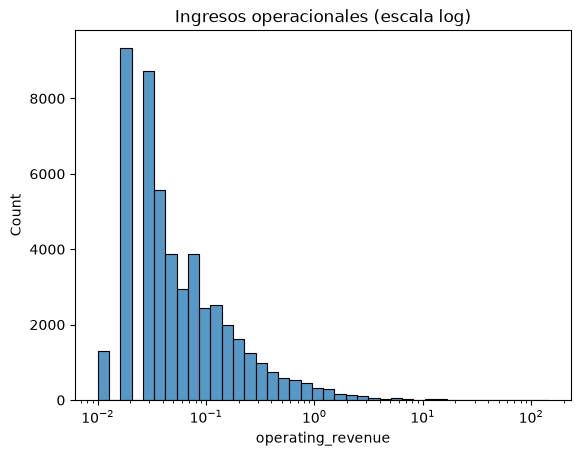

In [280]:
# Distribución de los ingresos (escala logarítmica porque son muy asimétricos)
sns.histplot(df["operating_revenue"], bins=40, log_scale=True)
plt.title("Ingresos operacionales (escala log)")
plt.show()

In [281]:
# Las cifras vienen redondeadas a 0.01 billones: muchas empresas tienen exactamente el mismo valor
print("Valores distintos de ingresos:", df["operating_revenue"].nunique())

# Proporción de registros con ingresos de 0.05 billones o menos
low_revenue_share = (df["operating_revenue"] <= 0.05).mean()
print(f"Registros con ingresos ≤ 0.05 billones: {low_revenue_share:.0%}")

# Valores de ingresos más repetidos
df["operating_revenue"].value_counts().head(8)

Valores distintos de ingresos: 503
Registros con ingresos ≤ 0.05 billones: 58%


operating_revenue
0.02    9337
0.03    8724
0.04    5571
0.05    3883
0.06    2954
0.07    2162
0.08    1700
0.09    1317
Name: count, dtype: int64

In [282]:
# Valores distintos por variable categórica
df[cat_cols].nunique()

supervisor       6
region          10
department      39
city           456
ciiu           427
macrosector      6
dtype: int64

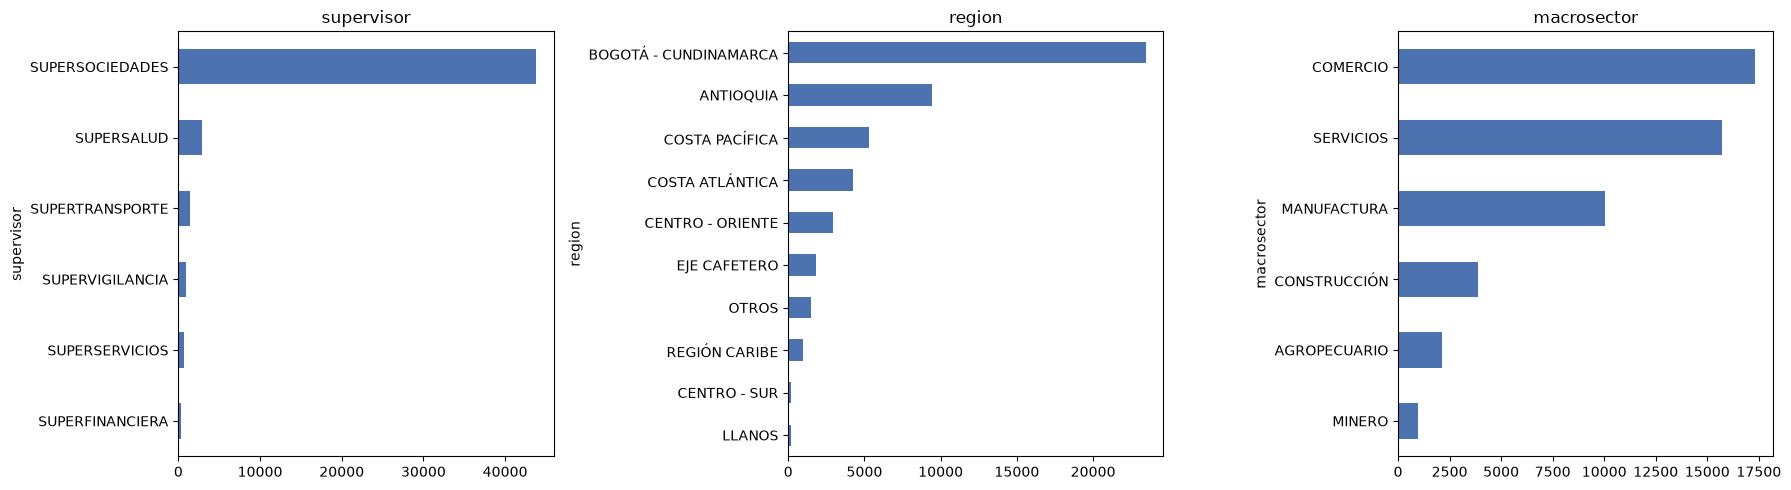

In [283]:
# Una fila con 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Un gráfico de barras por cada variable categórica
for ax, col in zip(axes, ["supervisor", "region", "macrosector"]):
    # Contar empresas por categoría y graficar barras horizontales ordenadas
    df[col].value_counts().sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(col)

plt.tight_layout()
plt.show()

<a id="sec-3-2"></a>
### 3.2 Multivariado

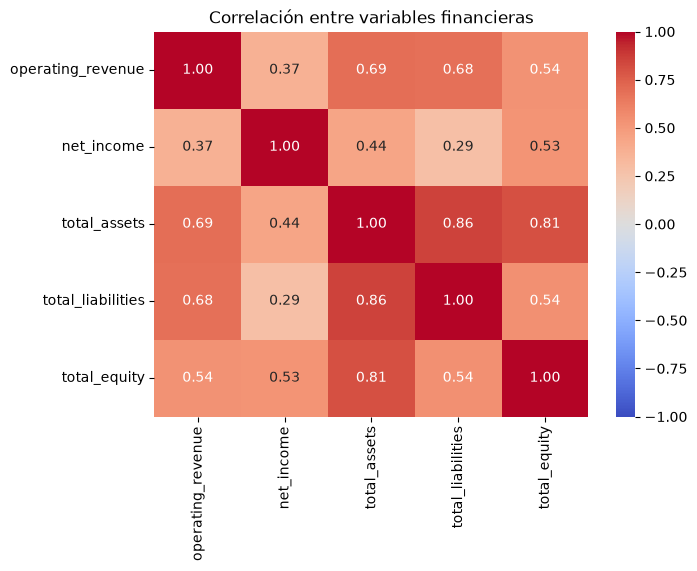

In [284]:
# Spearman: robusta a la fuerte asimetría de las variables financieras
plt.figure(figsize=(7, 5))
# Mapa de calor de las correlaciones
sns.heatmap(
    df[financial_cols].corr(method="spearman"),
    # Mostrar los valores con 2 decimales y escala de color fija de -1 a 1
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
)
plt.title("Correlación entre variables financieras")
plt.show()

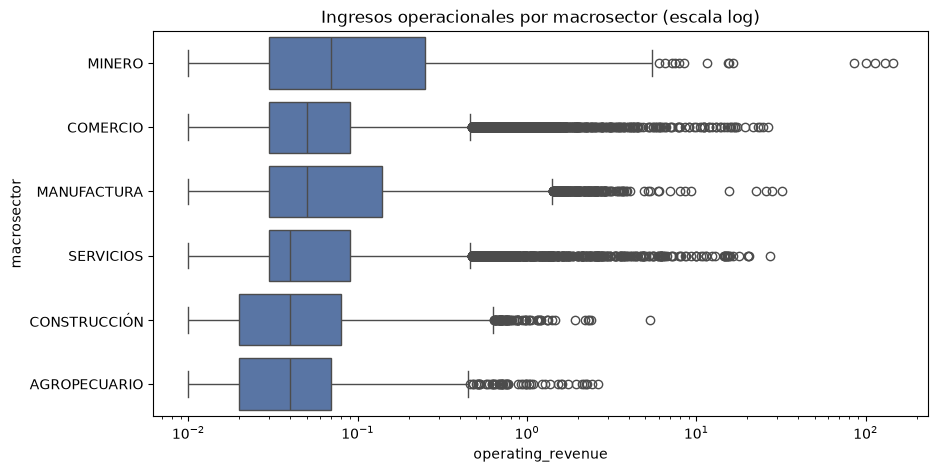

In [285]:
plt.figure(figsize=(10, 5))
# Escala logarítmica porque los ingresos son muy asimétricos
sns.boxplot(
    data=df,
    x="operating_revenue",
    y="macrosector",
    log_scale=True,
    color="#4C72B0",
)
plt.title("Ingresos operacionales por macrosector (escala log)")
plt.show()

<a id="sec-3-3"></a>
### 3.3 Cobertura del ranking por año
Las empresas incluidas cambian entre años y Supersalud desaparece en 2025.

In [286]:
pd.crosstab(df["supervisor"], df["year"])

year,2021,2022,2023,2024,2025
supervisor,,,,,
SUPERFINANCIERA,58,58,55,50,47
SUPERSALUD,921,787,710,467,0
SUPERSERVICIOS,3,2,205,210,244
SUPERSOCIEDADES,8818,8960,8536,8520,8916
SUPERTRANSPORTE,1,8,310,548,583
SUPERVIGILANCIA,199,185,184,205,210


<a id="sec-4"></a>
## 4. Limpieza de datos

<a id="sec-4-1"></a>
### 4.1 Duplicados

In [287]:
# Análisis de duplicados
print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

Cantidad de filas duplicadas: 0


In [288]:
# Duplicados considerando que cada empresa debería tener un único registro por año
dup_nit_year = df.duplicated(subset=["nit", "year"]).sum()
print(f'Filas con NIT repetido en el mismo año: {dup_nit_year}')

Filas con NIT repetido en el mismo año: 0


<a id="sec-4-2"></a>
### 4.2 Ciudad de domicilio
Se unifican variantes del mismo municipio (tildes, sufijos, nombres largos).

In [289]:
# Ver posibles variantes de city agrupando por prefijo

# Ciudades distintas (sin NaN)
unique_cities = pd.Series(df["city"].dropna().unique())

# Prefijos de 3 letras que agrupan más de una ciudad (posibles variantes del mismo nombre)
variants_by_prefix = (
    # Agrupar las ciudades por sus 3 primeras letras
    unique_cities.groupby(unique_cities.str[:3])
    # Juntar las ciudades de cada grupo en una lista
    .agg(list)
    # Dejar solo los prefijos con más de una ciudad
    .loc[lambda s: s.str.len() > 1]
)

# Mostrar cada prefijo con sus ciudades
for prefix, names in variants_by_prefix.items():
    print(f"Prefijo '{prefix}': {names}")

Prefijo 'ACA': ['ACACÍAS', 'ACACIAS']
Prefijo 'AGU': ['AGUAZUL', 'AGUACHICA']
Prefijo 'ALB': ['ALBANIA', 'ALBAN']
Prefijo 'AMA': ['AMAGÁ', 'AMAGA']
Prefijo 'AND': ['ANDALUCÍA', 'ANDES']
Prefijo 'ANS': ['ANSERMA', 'ANSERMANUEVO']
Prefijo 'APA': ['APARTADÓ', 'APARTADO']
Prefijo 'ARA': ['ARAUCA', 'ARAUQUITA', 'ARATOCA']
Prefijo 'ARM': ['ARMENIA', 'ARMERO']
Prefijo 'BAR': ['BARRANQUILLA', 'BARBOSA', 'BARRANCABERMEJA', 'BARANOA', 'BARRANCAS']
Prefijo 'BEL': ['BELLO', 'BELÉN', 'BELEN']
Prefijo 'BOJ': ['BOJACÁ', 'BOJACA']
Prefijo 'BOL': ['BOLÍVAR', 'BOLIVAR']
Prefijo 'BUC': ['BUCARAMANGA', 'BUCARASICA']
Prefijo 'BUE': ['BUENAVENTURA', 'BUENAVISTA', 'BUESACO']
Prefijo 'BUG': ['BUGA', 'BUGALAGRANDE']
Prefijo 'CAJ': ['CAJICÁ', 'CAJICA']
Prefijo 'CAL': ['CALI', 'CALOTO', 'CALDAS', 'CALIMA', 'CALARCÁ', 'CALAMAR', 'CALARCA']
Prefijo 'CAM': ['CAMPOALEGRE', 'CAMPO DE LA CRUZ', 'CAMPO ALEGRE']
Prefijo 'CAR': ['CARTAGENA', 'CARMEN DE VIBORAL', 'CARTAGO', 'CAREPA']
Prefijo 'CER': ['CERETÉ', 'CERETE']
Pr

In [290]:
# 1. Normalización general (quita tildes y diéresis de forma vectorizada)
df["city"] = (
    # Partir de la columna original
    df["city"]
    # Convertir a texto
    .astype(str)
    # Quitar espacios al inicio y al final
    .str.strip()
    # Separar cada letra de su tilde (á -> a + ´)
    .str.normalize("NFKD")
    # Pasar a ASCII descartando las tildes sueltas
    .str.encode("ascii", errors="ignore")
    # Convertir los bytes de vuelta a texto
    .str.decode("utf-8")
    # Pasar todo a mayúsculas
    .str.upper()
)

# 2. Diccionario de corrección para inconsistencias detectadas
city_map = {
    # Aglutinaciones y separación de palabras
    "DON MATIAS": "DONMATIAS",
    "DOS QUEBRADAS": "DOSQUEBRADAS",
    "CAMPO ALEGRE": "CAMPOALEGRE",
    # Sufijos departamentales y aclaraciones
    "MAICAO GUAJIRA": "MAICAO",
    "MITU VAUPES": "MITU",
    "PUERTO GAITAN (MANACACIAS)": "PUERTO GAITAN",
    "LA PAZ (ROBLES)": "LA PAZ",
    "SAN ANDRES Y PROVIDENCIA": "SAN ANDRES",
    # Nombres oficiales largos vs. comunes
    "GUADALAJARA DE BUGA": "BUGA",
    "VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA DE SAN DIEGO DE VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA ROSARIO": "VILLA DEL ROSARIO",
    # Variantes que aparecen en 2025
    "EL ESPINAL": "ESPINAL",
    "EL GUAMO": "GUAMO",
    "GIRALDOTA": "GIRARDOTA",
    # Textos corruptos o truncados
    "SAN SEBASTIAN DE BUENAVISMAGDALENA": "SAN SEBASTIAN DE BUENAVISTA",
}

df["city"] = df["city"].replace(city_map)

In [291]:
# Caso especial: Ferretería Central (Boyacá)
# 1. Localizar por coincidencia de la razón social
ferreteria_mask = df["company_name"].str.contains(
    # na=False: las razones sociales vacías cuentan como no coincidencia
    "FERRETERIA CENTRAL", na=False
# Y además que el departamento sea Boyacá
) & (df["department"] == "BOYACA")

# 2. Corregir ciudad y departamento
df.loc[ferreteria_mask, "city"] = "PUERTO BOYACA"
df.loc[ferreteria_mask, "department"] = "BOYACA"

# 3. Limpiar la razón social si absorbió el texto del departamento
df.loc[ferreteria_mask, "company_name"] = df.loc[
    ferreteria_mask, "company_name"
# Quitar "BOYACA" del final del nombre ($ = fin del texto) y los espacios sobrantes
].str.replace(r"BOYACA$", "", regex=True).str.strip()

<a id="sec-4-3"></a>
### 4.3 Departamento y región
Se unifican nombres, se corrigen cruces ciudad-departamento y se reconstruye la región desde el departamento.

In [292]:
# Ver posibles variantes de department agrupando por prefijo
unique_departments = pd.Series(df["department"].dropna().unique())

# Prefijos de 3 letras con sus departamentos
variants_by_prefix = (
    # Agrupar los departamentos por sus 3 primeras letras
    unique_departments.groupby(unique_departments.str[:3])
    # Juntar los departamentos de cada grupo en una lista
    .agg(list)
    # Dejar los prefijos con al menos un departamento
    .loc[lambda s: s.str.len() >= 1]
)

# Mostrar cada prefijo con sus departamentos
for prefix, names in variants_by_prefix.items():
    print(f"Prefijo '{prefix}': {names}")

Prefijo 'AMA': ['AMAZONAS']
Prefijo 'ANT': ['ANTIOQUIA']
Prefijo 'ARA': ['ARAUCA']
Prefijo 'ARM': ['ARMENIA']
Prefijo 'ATL': ['ATLANTICO']
Prefijo 'BOG': ['BOGOTA D.C.']
Prefijo 'BOL': ['BOLIVAR']
Prefijo 'BOY': ['BOYACA']
Prefijo 'CAL': ['CALDAS']
Prefijo 'CAQ': ['CAQUETA']
Prefijo 'CAS': ['CASANARE']
Prefijo 'CAU': ['CAUCA']
Prefijo 'CES': ['CESAR']
Prefijo 'CHO': ['CHOCO']
Prefijo 'COR': ['CORDOBA']
Prefijo 'CUN': ['CUNDINAMARCA']
Prefijo 'GUA': ['GUAVIARE', 'GUAJIRA', 'GUAINIA']
Prefijo 'HUI': ['HUILA']
Prefijo 'LA ': ['LA GUAJIRA']
Prefijo 'MAG': ['MAGDALENA']
Prefijo 'MET': ['META']
Prefijo 'MON': ['MONTERIA']
Prefijo 'NAR': ['NARINO', 'NARIÑO']
Prefijo 'NOR': ['NORTE DE SANTANDER']
Prefijo 'PUT': ['PUTUMAYO']
Prefijo 'QUI': ['QUINDIO']
Prefijo 'RIS': ['RISARALDA']
Prefijo 'SAN': ['SANTANDER', 'SAN ANDRES Y PROVIDENCIA']
Prefijo 'SUC': ['SUCRE']
Prefijo 'TOL': ['TOLIMA']
Prefijo 'VAL': ['VALLE DEL CAUCA', 'VALLE', 'VALLEDUPAR']
Prefijo 'VAU': ['VAUPES']
Prefijo 'VIC': ['VICHADA']

In [293]:
# 1. Normalizar a mayúsculas y remover caracteres especiales/eñes
df["department"] = (
    # Partir de la columna original
    df["department"]
    # Convertir a texto
    .astype(str)
    # Quitar espacios al inicio y al final
    .str.strip()
    # Separar cada letra de su tilde (á -> a + ´)
    .str.normalize("NFKD")
    # Pasar a ASCII descartando las tildes sueltas
    .str.encode("ascii", errors="ignore")
    # Convertir los bytes de vuelta a texto
    .str.decode("utf-8")
    # Pasar todo a mayúsculas
    .str.upper()
)

# 2. Reubicar ciudades que quedaron registradas en la columna de departamento
# Si city quedó vacía o alterada, se asegura el valor correcto
mask_armenia = df["department"] == "ARMENIA"
# Armenia es la capital del Quindío
df.loc[mask_armenia, "city"] = "ARMENIA"
df.loc[mask_armenia, "department"] = "QUINDIO"

mask_monteria = df["department"] == "MONTERIA"
# Montería es la capital de Córdoba
df.loc[mask_monteria, "city"] = "MONTERIA"
df.loc[mask_monteria, "department"] = "CORDOBA"

mask_valledupar = df["department"] == "VALLEDUPAR"
# Valledupar es la capital del Cesar
df.loc[mask_valledupar, "city"] = "VALLEDUPAR"
df.loc[mask_valledupar, "department"] = "CESAR"

# 3. Estandarizar nombres de departamentos duplicados
department_map = {
    "VALLE": "VALLE DEL CAUCA",
    "GUAJIRA": "LA GUAJIRA",
}

# Aplicar el mapeo
df["department"] = df["department"].replace(department_map)

In [294]:
# FASE 1: Corregir departamentos y errores tipográficos puntuales

# Errores territoriales donde la ciudad es evidente
# df.loc[filas, columna] = valor: cambia la columna solo en las filas que cumplen la condición
df.loc[df["city"] == "MEDELLIN", "department"] = (
    "ANTIOQUIA"
)
df.loc[df["city"] == "BARRANQUILLA", "department"] = (
    "ATLANTICO"
)
df.loc[df["city"] == "BUCARAMANGA", "department"] = (
    "SANTANDER"
)
df.loc[df["city"] == "PALMIRA", "department"] = (
    "VALLE DEL CAUCA"
)
df.loc[df["city"] == "RIOHACHA", "department"] = (
    "LA GUAJIRA"
)
df.loc[
    # isin: filas cuya ciudad está en la lista
    df["city"].isin(["CUCUTA", "OCANA", "BUCARASICA"]),
    "department",
] = "NORTE DE SANTANDER"
df.loc[
    df["city"].isin(["FUNZA", "COTA", "MOSQUERA"]),
    "department",
] = "CUNDINAMARCA"
df.loc[df["city"] == "LA TEBAIDA", "department"] = (
    "QUINDIO"
)
df.loc[df["city"] == "ARJONA", "department"] = (
    "BOLIVAR"
)

# Caso especial Bogotá (forzar siempre a Bogotá D.C. en ambas columnas)
mask_bogota = df["city"].isin(
    ["BOGOTA D.C.", "BOGOTA, D.C.", "BOGOTA"]
)
# Asignar el mismo valor a las dos columnas a la vez
df.loc[mask_bogota, ["city", "department"]] = (
    "BOGOTA D.C."
)

# Caso especial Anserma en Valle -> Ansermanuevo
df.loc[
    (df["city"] == "ANSERMA")
    # & exige que se cumplan las dos condiciones (cada una va entre paréntesis)
    & (df["department"] == "VALLE DEL CAUCA"),
    "city",
] = "ANSERMANUEVO"

# Typo en Risaralda: Satuario -> Santuario
df.loc[
    (df["city"] == "SATUARIO")
    & (df["department"] == "RISARALDA"),
    "city",
] = "SANTUARIO"


# FASE 2: Homologación a nombres oficiales DIVIPOLA

official_names = {
    # Ciudades principales y municipios con prefijos/sufijos omitidos
    "CALI": "SANTIAGO DE CALI",
    "CARTAGENA": "CARTAGENA DE INDIAS",
    "CUCUTA": "SAN JOSE DE CUCUTA",
    "BUGA": "GUADALAJARA DE BUGA",
    "UBATE": "VILLA DE SAN DIEGO DE UBATE",
    "CARMEN DE VIBORAL": "EL CARMEN DE VIBORAL",
    "TUMACO": "SAN ANDRES DE TUMACO",
    "SANTAFE DE ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
    "MARIQUITA": "SAN SEBASTIAN DE MARIQUITA",
    "PIENDAMO": "PIENDAMO - TUNIA",
    "SINCE": "SAN LUIS DE SINCE",
    "TOLU": "SANTIAGO DE TOLU",
    "INIRIDA GUAINIA": "INIRIDA",
    "ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
}

# Aplicar reemplazos directos
df["city"] = df["city"].replace(official_names)

# Casos con desambiguación contextual:
# San Pedro en Antioquia -> San Pedro de los Milagros
df.loc[
    (df["city"] == "SAN PEDRO")
    & (df["department"] == "ANTIOQUIA"),
    "city",
] = "SAN PEDRO DE LOS MILAGROS"

# Bolívar en Antioquia -> Ciudad Bolívar
df.loc[
    (df["city"] == "BOLIVAR")
    & (df["department"] == "ANTIOQUIA"),
    "city",
] = "CIUDAD BOLIVAR"

# Santuario en Antioquia -> El Santuario (en Risaralda el nombre oficial es "Santuario", sin "El").
# Por eso esta homologación se condiciona por departamento en vez de aplicarse a toda la columna
df.loc[
    (df["city"] == "SANTUARIO")
    & (df["department"] == "ANTIOQUIA"),
    "city",
] = "EL SANTUARIO"

In [295]:
# Verificación: ya no deben existir cruces ciudad-departamento imposibles
expected_bad_pairs = {
    "BOGOTA D.C.": ["ANTIOQUIA", "CUNDINAMARCA"],
    "MEDELLIN": ["MAGDALENA"],
    "BARRANQUILLA": ["BOLIVAR", "SAN ANDRES Y PROVIDENCIA"],
    "CUCUTA": ["SANTANDER"],
}

# Una condición (máscara booleana) por cada ciudad
conditions = []
for city, departments in expected_bad_pairs.items():
    # Filas con esa ciudad y alguno de sus departamentos imposibles
    cond = (df["city"] == city) & (
        df["department"].isin(departments)
    )
    conditions.append(cond)

# Unir las máscaras como columnas y marcar las filas que cumplan al menos una
anomaly_mask = pd.concat(conditions, axis=1).any(axis=1)
# Filas anómalas con solo las columnas útiles para revisarlas
df_anomalies = df.loc[
    anomaly_mask,
    ["nit", "company_name", "city", "department", "year"],
]

print(f"Total de filas con cruces anómalos detectadas: {len(df_anomalies)}")
# to_string muestra la tabla completa, sin el índice
print(df_anomalies.to_string(index=False))

# 2. Contar cuántas ciudades únicas aparecen en más de un departamento
multi_department_cities = (
    # Agrupar por ciudad y tomar su departamento
    df.groupby("city")["department"]
    # Contar departamentos distintos por ciudad
    .nunique()
    # Dejar solo las ciudades con más de un departamento
    .loc[lambda x: x > 1]
)

print(f"\nTotal de nombres de ciudad asociados a >1 departamento: {len(multi_department_cities)}")
print(multi_department_cities.head(15))

Total de filas con cruces anómalos detectadas: 0
Empty DataFrame
Columns: [nit, company_name, city, department, year]
Index: []

Total de nombres de ciudad asociados a >1 departamento: 5
city
GRANADA     2
GUAMAL      2
LA UNION    3
LA VEGA     2
RESTREPO    2
Name: department, dtype: int64


In [296]:
# Homónimos legítimos: municipios distintos con el mismo nombre
homonyms = ["EL SANTUARIO", "GRANADA", "GUAMAL", "LA UNION", "LA VEGA", "RESTREPO"]

# Ver en qué departamentos aparece cada homónimo
print(
    # Filtrar los homónimos y quedarse con ciudad y departamento
    df[df["city"].isin(homonyms)][
        ["city", "department"]
    ]
    # Quitar combinaciones repetidas
    .drop_duplicates()
    # Ordenar por ciudad y luego por departamento
    .sort_values(by=["city", "department"])
    # Convertir a texto sin el índice
    .to_string(index=False)
)

        city      department
EL SANTUARIO       ANTIOQUIA
     GRANADA    CUNDINAMARCA
     GRANADA            META
      GUAMAL       MAGDALENA
      GUAMAL            META
    LA UNION       ANTIOQUIA
    LA UNION          NARINO
    LA UNION VALLE DEL CAUCA
     LA VEGA           CAUCA
     LA VEGA    CUNDINAMARCA
    RESTREPO            META
    RESTREPO VALLE DEL CAUCA


In [297]:
# Verificar la lista final de departamentos/entidades territoriales
sorted_departments = sorted(df["department"].dropna().unique())
print(f"Total entidades territoriales encontradas: {len(sorted_departments)}")
print(sorted_departments)

Total entidades territoriales encontradas: 33
['AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', 'BOGOTA D.C.', 'BOLIVAR', 'BOYACA', 'CALDAS', 'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA', 'GUAINIA', 'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARINO', 'NORTE DE SANTANDER', 'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SAN ANDRES Y PROVIDENCIA', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA', 'VAUPES', 'VICHADA']


In [298]:
# En 2025 cambian los nombres de las regiones y en 2021-2024 hay asignaciones inconsistentes.
# Se reconstruye la región desde el departamento, con la clasificación de 2025.
region_by_department = (
    # Tomar solo 2025
    df[df["year"] == 2025]
    # Agrupar por departamento y tomar la región
    .groupby("department")["region"]
    # Quedarse con la región más frecuente de cada departamento
    .agg(lambda s: s.mode()[0])
    .to_dict()
)
# Guainía no aparece en 2025, así que se asigna igual que Vaupés y Vichada
region_by_department["GUAINIA"] = "LLANOS"

df["region"] = df["department"].map(region_by_department)
print("Registros sin región:", df["region"].isna().sum())
df.groupby("region")["department"].unique()

Registros sin región: 0


region
ANTIOQUIA                                                      [ANTIOQUIA]
BOGOTÁ - CUNDINAMARCA                          [BOGOTA D.C., CUNDINAMARCA]
CENTRO - ORIENTE                   [SANTANDER, NORTE DE SANTANDER, BOYACA]
CENTRO - SUR                  [HUILA, TOLIMA, CAQUETA, PUTUMAYO, AMAZONAS]
COSTA PACÍFICA                     [VALLE DEL CAUCA, CAUCA, NARINO, CHOCO]
EJE CAFETERO                                  [RISARALDA, CALDAS, QUINDIO]
LLANOS                   [META, CASANARE, ARAUCA, GUAVIARE, VAUPES, VIC...
REGIÓN CARIBE            [BOLIVAR, ATLANTICO, MAGDALENA, SUCRE, CORDOBA...
Name: department, dtype: object

<a id="sec-4-4"></a>
### 4.4 Razón social por NIT
Un NIT puede tener varios nombres en distintos años. Se conserva el más reciente.

In [299]:
# 1. Agrupar por NIT y contar cuántas razones sociales distintas tiene asociadas
nits_with_several_names = (
    # Agrupar por NIT y tomar la razón social
    df.groupby("nit")["company_name"]
    # Contar razones sociales distintas por NIT
    .nunique()
    # Dejar solo los NIT con más de una
    .loc[lambda x: x > 1]
)

print(f"Total de NITs con más de una razón social: {len(nits_with_several_names)}")

# 2. Filtrar el DataFrame original para inspeccionar los casos conflictivos
inconsistent_cases = (
    # Filtrar los NIT conflictivos y quedarse con NIT, nombre y año
    df[df["nit"].isin(nits_with_several_names.index)][
        ["nit", "company_name", "year"]
    ]
    # Quitar filas repetidas
    .drop_duplicates()
    # Ordenar por NIT y año
    .sort_values(by=["nit", "year"])
)

# Mostrar los primeros casos
print("\nEjemplo de empresas con nombres cambiantes:")
print(inconsistent_cases.head(20).to_string(index=False))

Total de NITs con más de una razón social: 3707

Ejemplo de empresas con nombres cambiantes:
      nit                                                                                 company_name  year
800000118 EMPRESA SOCIAL DEL ESTADO HOSPITAL  DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS  2021
800000118 EMPRESA SOCIAL DEL ESTADO HOSPITAL  DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS  2022
800000118  EMPRESA SOCIAL DEL ESTADO HOSPITAL DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS  2023
800000457                                                       ACOMEDIOS PUBLICIDAD Y MERCADEO S.A.S.  2021
800000457                                                       ACOMEDIOS PUBLICIDAD Y MERCADEO S.A.S.  2023
800000457                                                       ACOMEDIOS PUBLICIDAD Y MERCADEO S.A.S.  2024
800000457                                                    ACOMEDIOS PUBLICIDAD Y MERCADEO LIMITADA.  2025
800001845                          

In [300]:
# 1. Normalizar espacios en blanco internos y bordes
df["company_name"] = (
    # Partir de la columna original
    df["company_name"]
    # Convertir a texto
    .astype(str)
    # Quitar espacios al inicio y al final
    .str.strip()
    # Reducir espacios repetidos a uno solo
    .str.replace(r"\s+", " ", regex=True)
)

# 2. Obtener el nombre del año más reciente por NIT
latest_name = (
    # Ordenar por NIT y año (del más antiguo al más reciente)
    df.sort_values(by=["nit", "year"], ascending=[True, True])
    # Agrupar por NIT y tomar la razón social
    .groupby("nit")["company_name"]
    # Quedarse con el último nombre (el del año más reciente)
    .last()
)

# 3. Sobreescribir
# map: a cada fila le asigna el nombre más reciente de su NIT
df["company_name"] = df["nit"].map(latest_name)

In [301]:
# Verificar que ya no existan NIT con más de un nombre asociado
print("NITs con más de un nombre:", (df.groupby("nit")["company_name"].nunique() > 1).sum())

NITs con más de un nombre: 0


<a id="sec-4-5"></a>
### 4.5 Activos totales en cero

In [302]:
# Registros con activos en 0
zero_assets = df["total_assets"] == 0
print("Registros con activos en 0:", zero_assets.sum())

# ¿Dato faltante o redondeo? Se revisan los activos de esas mismas empresas en los otros años
zero_assets_nits = df.loc[zero_assets, "nit"]
same_companies = df["nit"].isin(zero_assets_nits) & ~zero_assets
median_other_years = df.loc[same_companies, "total_assets"].median()
print("Mediana de sus activos en otros años:", median_other_years)

Registros con activos en 0: 1429
Mediana de sus activos en otros años: 0.01


En otros años esas empresas también tienen activos de casi 0: es el redondeo, no datos faltantes. Se conservan.

<a id="sec-4-6"></a>
### 4.6 Entidades de Supersalud
Supersalud desaparece del ranking en 2025, así que sus empresas se excluyen.

In [303]:
# Registros vigilados por Supersalud
is_supersalud = df["supervisor"] == "SUPERSALUD"
records_per_year = df[is_supersalud].groupby("year").size()
print("Registros de Supersalud por año:", records_per_year.to_dict())

# Quitarlos
df = df[~is_supersalud].reset_index(drop=True)
print("Registros restantes:", len(df))

Registros de Supersalud por año: {2021: 921, 2022: 787, 2023: 710, 2024: 467}
Registros restantes: 47115


<a id="sec-5"></a>
## 5. Preparación de datos

<a id="sec-5-1"></a>
### 5.1 Variable objetivo
next_year_distress vale 1 si el año siguiente la empresa tiene pérdidas o patrimonio negativo.

In [304]:
# Datos del año siguiente: se resta 1 al año para pegarlos a la fila del año actual
next_year = df[["nit", "year", "net_income", "total_equity"]].copy()
next_year["year"] -= 1
next_year.columns = ["nit", "year", "next_net_income", "next_equity"]

# Datos del año anterior: se suma 1 al año
prev_year = df[["nit", "year", "operating_revenue", "total_assets"]].copy()
prev_year["year"] += 1
prev_year.columns = ["nit", "year", "prev_revenue", "prev_assets"]

# Pegar ambos a cada fila (quedan vacíos si la empresa no aparece ese año)
df = df.merge(next_year, on=["nit", "year"], how="left")
df = df.merge(prev_year, on=["nit", "year"], how="left")

# Quitar los registros sin año siguiente (todo 2025 y las empresas que salen del ranking)
df = df.dropna(subset=["next_net_income"]).reset_index(drop=True)

# Variable objetivo: 1 si el año siguiente hay pérdidas o patrimonio negativo
next_losses = df["next_net_income"] < 0
next_negative_equity = df["next_equity"] < 0
df["next_year_distress"] = (next_losses | next_negative_equity).astype(int)

# Proporción (mean) y número (sum) de empresas con dificultades al año siguiente
df.groupby("year")["next_year_distress"].agg(["mean", "sum"]).round(3)

,mean,sum
year,,
2021,0.043,334
2022,0.051,386
2023,0.063,517
2024,0.052,441


<a id="sec-5-2"></a>
### 5.2 Variables nuevas

In [305]:
# Crecimiento frente al año anterior (0.1 = creció 10 %). Queda vacío si la empresa no estaba
df["revenue_growth"] = df["operating_revenue"] / df["prev_revenue"] - 1
df["asset_growth"] = df["total_assets"] / df["prev_assets"] - 1

# 1 si este año ya tiene pérdidas o patrimonio negativo
current_losses = df["net_income"] < 0
current_negative_equity = df["total_equity"] < 0
df["current_distress"] = (current_losses | current_negative_equity).astype(int)

# Indicadores financieros
df["net_margin"] = df["net_income"] / df["operating_revenue"]
df["debt_ratio"] = df["total_liabilities"] / df["total_assets"]
df["roa"] = df["net_income"] / df["total_assets"]

# División CIIU: los 2 primeros dígitos del código
df["ciiu_division"] = df["ciiu"].str[:2]

# Las divisiones por 0 (activos en 0) dan infinito: se dejan vacías
df = df.replace([np.inf, -np.inf], np.nan)

new_cols = [
    "revenue_growth",
    "asset_growth",
    "current_distress",
    "net_margin",
    "debt_ratio",
    "roa",
]
df[new_cols].describe().round(2)

,revenue_growth,asset_growth,current_distress,net_margin,debt_ratio,roa
count,21234.00,20746.00,32043.00,32043.00,31237.00,31237.00
mean,0.17,0.14,0.05,0.04,0.56,0.03
std,0.64,0.55,0.21,0.29,0.34,0.14
min,-0.95,-1.00,0.00,-15.00,0.00,-3.00
25%,0.00,0.00,0.00,0.00,0.33,0.00
50%,0.00,0.00,0.00,0.00,0.50,0.00
75%,0.33,0.22,0.00,0.02,0.75,0.03
max,49.00,57.00,1.00,25.00,7.12,13.50


In [306]:
# ¿Las empresas con dificultades hoy las repiten el año siguiente? (proporción por fila)
pd.crosstab(df["current_distress"], df["next_year_distress"], normalize="index").round(3)

next_year_distress,0,1
current_distress,,
0,0.973,0.027
1,0.432,0.568


<a id="sec-5-3"></a>
### 5.3 Tabla final y exportación

In [307]:
final_cols = [
    "nit",
    "company_name",
    "year",
    *cat_cols,
    "ciiu_division",
    *financial_cols,
    *new_cols,
    "next_year_distress",
]

df_clean = (
    # Ordenar por NIT y año
    df.sort_values(["nit", "year"])
    # Quedarse solo con las columnas finales
    [final_cols]
    # Reiniciar el índice desde 0
    .reset_index(drop=True)
)

df_clean.info()
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 32043 entries, 0 to 32042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nit                 32043 non-null  str    
 1   company_name        32043 non-null  str    
 2   year                32043 non-null  int64  
 3   supervisor          32043 non-null  str    
 4   region              32043 non-null  str    
 5   department          32043 non-null  str    
 6   city                32043 non-null  str    
 7   ciiu                32043 non-null  object 
 8   macrosector         32043 non-null  str    
 9   ciiu_division       32043 non-null  object 
 10  operating_revenue   32043 non-null  float64
 11  net_income          32043 non-null  float64
 12  total_assets        32043 non-null  float64
 13  total_liabilities   32043 non-null  float64
 14  total_equity        32043 non-null  float64
 15  revenue_growth      21234 non-null  float64
 16  asset_growth   

,nit,company_name,year,supervisor,region,department,city,ciiu,macrosector,ciiu_division,...,total_assets,total_liabilities,total_equity,revenue_growth,asset_growth,current_distress,net_margin,debt_ratio,roa,next_year_distress
0,800000276,AVICOLA EL MADROÑO S.A.,2021,SUPERSOCIEDADES,CENTRO - ORIENTE,SANTANDER,BUCARAMANGA,0145,AGROPECUARIO,01,...,0.22,0.14,0.08,NaN,NaN,0,0.021739,0.636364,0.045455,0
1,800000276,AVICOLA EL MADROÑO S.A.,2022,SUPERSOCIEDADES,CENTRO - ORIENTE,SANTANDER,BUCARAMANGA,0145,AGROPECUARIO,01,...,0.28,0.18,0.10,0.391304,0.272727,0,0.031250,0.642857,0.071429,0
2,800000276,AVICOLA EL MADROÑO S.A.,2023,SUPERSOCIEDADES,CENTRO - ORIENTE,SANTANDER,BUCARAMANGA,0145,AGROPECUARIO,01,...,0.27,0.17,0.10,0.062500,-0.035714,0,0.014706,0.629630,0.037037,0
3,800000276,AVICOLA EL MADROÑO S.A.,2024,SUPERSOCIEDADES,CENTRO - ORIENTE,SANTANDER,BUCARAMANGA,0145,AGROPECUARIO,01,...,0.30,0.19,0.12,0.044118,0.111111,0,0.028169,0.633333,0.066667,0
4,800000457,ACOMEDIOS PUBLICIDAD Y MERCADEO LIMITADA.,2023,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,BOGOTA D.C.,7310,SERVICIOS,73,...,0.02,0.01,0.01,NaN,NaN,0,0.000000,0.500000,0.000000,0


In [308]:
# Exportar resultados
output_path = 'data/proccesed/10.000_Empresas_mas_Grandes_del_País_proccesed.csv'
df_clean.to_csv(output_path, index=False)

<a id="sec-6"></a>
## 6. Modelado
Se entrena con 2022 y 2023 y se prueba con 2024. 2021 no se usa porque no tiene año anterior.

<a id="sec-6-1"></a>
### 6.1 Datos para el modelo

In [309]:
# Variables del modelo (región y ciudad se omiten porque las cubre el departamento)
model_cat_cols = ["supervisor", "department", "ciiu_division", "macrosector"]
model_num_cols = financial_cols + new_cols

X = df_clean[model_cat_cols + model_num_cols]
y = df_clean["next_year_distress"].to_numpy()
year = df_clean["year"].to_numpy()

# División por año: Optuna entrena con 2022 y valida con 2023
is_train = year == 2022
is_val = year == 2023
is_test = year == 2024
# Los modelos finales se entrenan con 2022 y 2023
is_final = is_train | is_val

print("Filas:", is_train.sum(), is_val.sum(), is_test.sum())

Filas: 7518 8229 8503


In [310]:
# Categóricas: una columna 0/1 por categoría. Las que tienen menos de 20 empresas se agrupan
categorical = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=20,
    sparse_output=False,
)

# Numéricas: llevar a distribución normal por cuantiles y rellenar los vacíos con la mediana
numerical = make_pipeline(
    QuantileTransformer(output_distribution="normal", random_state=42),
    SimpleImputer(strategy="median", add_indicator=True),
)

preprocessor = ColumnTransformer([
    ("cat", categorical, model_cat_cols),
    ("num", numerical, model_num_cols),
])

# Se ajusta solo con entrenamiento y se aplica a todas las filas
preprocessor.fit(X[is_train])
X_prep = preprocessor.transform(X)
X_prep.shape

(32043, 101)

In [311]:
def flag_at_risk(prob):
    # Número de empresas que forman el 10 % más alto
    n_at_risk = round(len(prob) * 0.1)
    # Posiciones de las empresas, de mayor a menor riesgo
    order = np.argsort(-prob, kind="stable")
    # 1 = en riesgo, 0 = no. Si hay empates, igual se marca el número exacto de empresas
    flags = np.zeros(len(prob), dtype=int)
    flags[order[:n_at_risk]] = 1
    return flags

In [312]:
def compute_metrics(prob, pred, actual):
    return {
        # Qué tan bien ordena a las empresas por riesgo: 0.5 = azar, 1 = perfecto
        "AUC": roc_auc_score(actual, prob),
        # Proporción de empresas bien clasificadas, con y sin dificultades
        "Accuracy": accuracy_score(actual, pred),
        # De las empresas marcadas en riesgo, cuántas tuvieron dificultades
        "Precisión": precision_score(actual, pred),
        # De las empresas que tuvieron dificultades, cuántas fueron marcadas
        "Recall": recall_score(actual, pred),
    }

<a id="sec-6-2"></a>
### 6.2 Balanceo con SMOTE
Solo cerca del 5 % de las empresas tiene dificultades al año siguiente, así que los modelos ven pocos ejemplos de esa clase.

In [313]:
# SMOTE toma una empresa con dificultades y una de sus 5 vecinas más parecidas,
# y crea una empresa nueva en un punto intermedio entre las dos
smote = SMOTE(random_state=42)

# Entrenamiento para buscar hiperparámetros (2022)
X_train_bal, y_train_bal = smote.fit_resample(X_prep[is_train], y[is_train])
# Entrenamiento de los modelos finales (2022 y 2023)
X_final_bal, y_final_bal = smote.fit_resample(X_prep[is_final], y[is_final])

# Empresas sin y con dificultades, antes y después
print("Antes:", np.bincount(y[is_final]))
print("Después:", np.bincount(y_final_bal))

Antes: [14844   903]
Después: [14844 14844]


<a id="sec-6-3"></a>
### 6.3 Regresión logística

In [314]:
# Probabilidades y predicciones sí/no en test de cada modelo
prob_test = {}
pred_test = {}

logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_final_bal, y_final_bal)

# Columna 1 = probabilidad de dificultades
prob_test["Regresión logística"] = logistic.predict_proba(X_prep[is_test])[:, 1]
pred_test["Regresión logística"] = flag_at_risk(prob_test["Regresión logística"])

<a id="sec-6-4"></a>
### 6.4 Naive Bayes

In [315]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_final_bal, y_final_bal)

# Sus probabilidades se pegan a 0 o a 1, así que muchas empresas empatan.
# La diferencia de log-probabilidades entre las dos clases ordena igual y sin empates
log_prob = naive_bayes.predict_joint_log_proba(X_prep[is_test])
prob_test["Naive Bayes"] = log_prob[:, 1] - log_prob[:, 0]
pred_test["Naive Bayes"] = flag_at_risk(prob_test["Naive Bayes"])

<a id="sec-6-5"></a>
### 6.5 K vecinos más cercanos

In [316]:
auc_by_k = {}
for k in [25, 50, 100, 200, 400]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_bal, y_train_bal)
    # Proporción de los k vecinos que tuvo dificultades
    prob_val = knn.predict_proba(X_prep[is_val])[:, 1]
    auc_by_k[k] = roc_auc_score(y[is_val], prob_val)

# k con mayor AUC de validación
best_k = max(auc_by_k, key=auc_by_k.get)
print("Mejor k:", best_k)

# Modelo final con 2022 y 2023
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_final_bal, y_final_bal)

prob_test["K vecinos"] = knn.predict_proba(X_prep[is_test])[:, 1]
pred_test["K vecinos"] = flag_at_risk(prob_test["K vecinos"])

Mejor k: 400


<a id="sec-6-6"></a>
### 6.6 SVM

In [317]:
# Probar varios C: entrenar con 2022 balanceado y medir el AUC en 2023
auc_by_c = {}
for c_value in [0.1, 1, 10]:
    # C bajo = frontera más suave, C alto = frontera más pegada a los datos
    svm = SVC(kernel="rbf", C=c_value)
    svm.fit(X_train_bal, y_train_bal)
    # SVM no da probabilidades. Su puntaje es la distancia a la frontera y sirve igual para ordenar
    score_val = svm.decision_function(X_prep[is_val])
    auc_by_c[c_value] = roc_auc_score(y[is_val], score_val)

# C con mayor AUC de validación
best_c = max(auc_by_c, key=auc_by_c.get)
print("Mejor C:", best_c)

# Modelo final con 2022 y 2023
svm = SVC(kernel="rbf", C=best_c)
svm.fit(X_final_bal, y_final_bal)

prob_test["SVM"] = svm.decision_function(X_prep[is_test])
pred_test["SVM"] = flag_at_risk(prob_test["SVM"])

Mejor C: 0.1


<a id="sec-6-7"></a>
### 6.7 Árbol de decisión

In [318]:
# Probar varias profundidades: entrenar con 2022 balanceado y medir el AUC en 2023
auc_by_depth = {}
for depth in range(2, 13):
    # min_samples_leaf evita hojas con muy pocas empresas
    tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    tree.fit(X_train_bal, y_train_bal)
    prob_val = tree.predict_proba(X_prep[is_val])[:, 1]
    auc_by_depth[depth] = roc_auc_score(y[is_val], prob_val)

# Profundidad con mayor AUC de validación
best_depth = max(auc_by_depth, key=auc_by_depth.get)
print("Mejor profundidad:", best_depth)

# Árbol final con 2022 y 2023
tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=20, random_state=42)
tree.fit(X_final_bal, y_final_bal)

prob_test["Árbol de decisión"] = tree.predict_proba(X_prep[is_test])[:, 1]
pred_test["Árbol de decisión"] = flag_at_risk(prob_test["Árbol de decisión"])

Mejor profundidad: 6


<a id="sec-6-8"></a>
### 6.8 Random forest con grid search

In [319]:
X_search = np.vstack([X_train_bal, X_prep[is_val]])
y_search = np.concatenate([y_train_bal, y[is_val]])

fold = np.concatenate([np.full(len(y_train_bal), -1), np.zeros(is_val.sum())])
fixed_split = PredefinedSplit(fold)

In [320]:
param_grid = {
    # Profundidad máxima de cada árbol (None = sin límite)
    "max_depth": [None, 10, 20],
    # Mínimo de empresas en cada hoja
    "min_samples_leaf": [1, 5, 10, 20],
    # Variables que mira cada división: raíz cuadrada del total o el 30 %
    "max_features": ["sqrt", 0.3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=fixed_split,
    # El modelo final se entrena aparte con 2022 y 2023
    refit=False,
)
grid_search.fit(X_search, y_search)
print("Mejores hiperparámetros:", grid_search.best_params_)

# Modelo final con 2022 y 2023
rf_grid = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=42, **grid_search.best_params_
)
rf_grid.fit(X_final_bal, y_final_bal)

prob_test["RF grid search"] = rf_grid.predict_proba(X_prep[is_test])[:, 1]
pred_test["RF grid search"] = flag_at_risk(prob_test["RF grid search"])

Mejores hiperparámetros: {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 20}


<a id="sec-6-9"></a>
### 6.9 Random forest con búsqueda bayesiana

In [321]:
def rf_objective(trial):
    # Hiperparámetros que Optuna prueba en cada intento
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
        "max_features": trial.suggest_float("max_features", 0.05, 0.6),
    }

    # Entrenar con 2022 balanceado y medir el AUC en 2023
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42, **params)
    rf.fit(X_train_bal, y_train_bal)
    prob_val = rf.predict_proba(X_prep[is_val])[:, 1]
    return roc_auc_score(y[is_val], prob_val)

In [322]:
# Buscar los hiperparámetros con mayor AUC de validación
sampler = optuna.samplers.TPESampler(seed=42)
rf_study = optuna.create_study(direction="maximize", sampler=sampler)
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Mejores hiperparámetros:", rf_study.best_params)

# Modelo final con 2022 y 2023
rf_bayes = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=42, **rf_study.best_params
)
rf_bayes.fit(X_final_bal, y_final_bal)

prob_test["RF bayesiana"] = rf_bayes.predict_proba(X_prep[is_test])[:, 1]
pred_test["RF bayesiana"] = flag_at_risk(prob_test["RF bayesiana"])

  0%|          | 0/30 [00:00<?, ?it/s]

Mejores hiperparámetros: {'max_depth': 15, 'min_samples_leaf': 19, 'max_features': 0.15982058018709783}


<a id="sec-6-10"></a>
### 6.10 Red neuronal

In [323]:
class NeuralNet(nn.Module):
    def __init__(self, n_inputs, n_layers, n_neurons, dropout):
        super().__init__()
        # Lista donde se van armando las capas
        layers = []
        # Cada capa oculta: lineal + ReLU + dropout
        for _ in range(n_layers):
            layers += [nn.Linear(n_inputs, n_neurons), nn.ReLU(), nn.Dropout(dropout)]
            # La siguiente capa recibe la salida de esta
            n_inputs = n_neurons
        # Capa de salida con un único valor
        layers.append(nn.Linear(n_inputs, 1))
        # Encadenar todas las capas en orden
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [324]:
def train_net(params, X_np, y_np):
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_np, dtype=torch.float32, device=device).unsqueeze(1)

    # Crear la red con los hiperparámetros elegidos
    net = NeuralNet(
        n_inputs=X_t.shape[1],
        n_layers=params["n_layers"],
        n_neurons=params["n_neurons"],
        dropout=params["dropout"],
    ).to(device)

    # Adam ajusta los pesos y la pérdida es la de clasificación binaria (sí / no)
    optimizer = torch.optim.Adam(net.parameters(), lr=params["lr"])
    loss_fn = nn.BCEWithLogitsLoss()

    net.train()
    for _ in range(params["epochs"]):
        # Filas en orden aleatorio, partidas en lotes de 256
        batches = torch.randperm(len(X_t), device=device).split(256)
        for batch in batches:
            # Reiniciar los gradientes
            optimizer.zero_grad()
            # Error de la red en este lote
            loss = loss_fn(net(X_t[batch]), y_t[batch])
            # Calcular los gradientes y actualizar los pesos
            loss.backward()
            optimizer.step()

    return net

In [325]:
def predict_net(net, X_np):
    # Modo evaluación: apaga el dropout
    net.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)

    # Sin calcular gradientes, porque solo se predice
    with torch.no_grad():
        output = net(X_t)

    # sigmoid convierte la salida en una probabilidad entre 0 y 1
    return torch.sigmoid(output).cpu().numpy().ravel()

In [326]:
def net_objective(trial):
    # Hiperparámetros que Optuna prueba en cada intento
    params = {
        "n_layers": trial.suggest_int("n_layers", 1, 3),
        "n_neurons": trial.suggest_int("n_neurons", 16, 256, log=True),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "epochs": trial.suggest_int("epochs", 5, 50),
    }

    # Entrenar con 2022 balanceado y medir el AUC en 2023
    net = train_net(params, X_train_bal, y_train_bal)
    prob_val = predict_net(net, X_prep[is_val])
    return roc_auc_score(y[is_val], prob_val)

In [327]:
# Buscar los hiperparámetros con mayor AUC de validación
sampler = optuna.samplers.TPESampler(seed=42)
net_study = optuna.create_study(direction="maximize", sampler=sampler)
net_study.optimize(net_objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Mejores hiperparámetros:", net_study.best_params)

# Red final con 2022 y 2023
net = train_net(net_study.best_params, X_final_bal, y_final_bal)

prob_test["Red neuronal"] = predict_net(net, X_prep[is_test])
pred_test["Red neuronal"] = flag_at_risk(prob_test["Red neuronal"])

  0%|          | 0/30 [00:00<?, ?it/s]

Mejores hiperparámetros: {'n_layers': 2, 'n_neurons': 180, 'dropout': 0.4708068863303985, 'lr': 0.00021206087185155482, 'epochs': 10}


<a id="sec-6-11"></a>
### 6.11 Comparación en test

In [328]:
rows = {}
for name in prob_test:
    rows[name] = compute_metrics(prob_test[name], pred_test[name], y[is_test])

results = pd.DataFrame(rows).T
results.sort_values("AUC", ascending=False).round(3)

,AUC,Accuracy,Precisión,Recall
Red neuronal,0.902,0.918,0.347,0.669
RF grid search,0.901,0.917,0.344,0.662
RF bayesiana,0.901,0.916,0.338,0.651
Regresión logística,0.898,0.918,0.348,0.671
K vecinos,0.891,0.916,0.339,0.653
SVM,0.882,0.917,0.342,0.660
Árbol de decisión,0.881,0.910,0.308,0.594
Naive Bayes,0.810,0.907,0.296,0.571


<a id="sec-6-12"></a>
### 6.12 Matrices de confusión

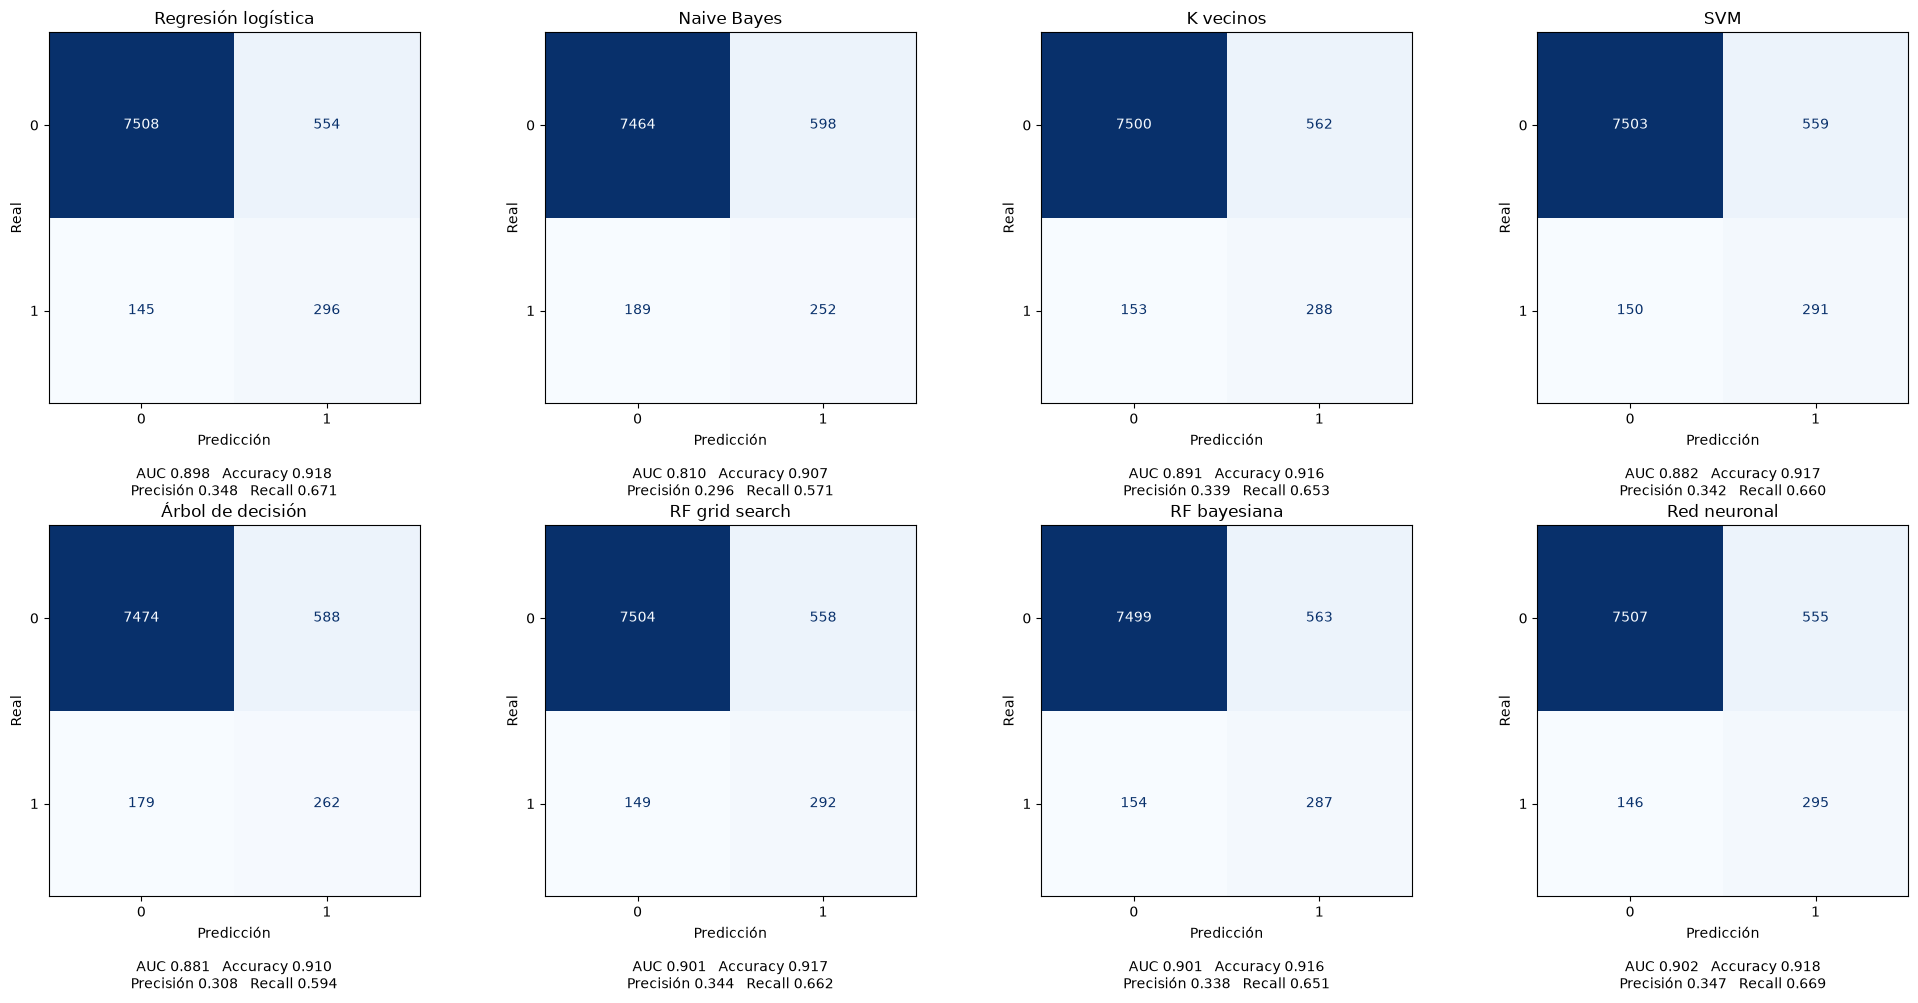

In [330]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, name in zip(axes.ravel(), pred_test):
    ConfusionMatrixDisplay.from_predictions(
        y[is_test],
        pred_test[name],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_ylabel("Real")
    # Métricas del modelo debajo de su matriz
    model_metrics = results.loc[name]
    ax.set_xlabel(
        "Predicción\n\n"
        f"AUC {model_metrics['AUC']:.3f}   Accuracy {model_metrics['Accuracy']:.3f}\n"
        f"Precisión {model_metrics['Precisión']:.3f}   Recall {model_metrics['Recall']:.3f}"
    )

plt.tight_layout()
plt.show()